# Compositional Generalization in Linear Networks

In [9]:
%matplotlib widget

In [10]:
import jax
import jax.numpy as jnp
import numpy as np
from math import prod

from task import get_data
from network import init_shallow, init_deep
from network_aux import loss_fn
from train import train
from plotting import plot_data_kernels, plot_loss_curves, plot_shallow_kernels, plot_deep_kernels, plot_effective_svd

# Config
BRANCHING = (2, 3, 4)
D = 256*4       # observation dimension
N_LEAVES = prod(BRANCHING)
N = 256*4      # hidden width
KAPPA0 = 1e-1 # inverse temperature (prior / data balance)
DS = 1e-3     # discretization step size
S_MAX = 10000.0  # continuous training time (max_steps = s_max / ds)
DEPTH = 3     # depth for deep network
MUP = True   # toggle maximal update parametrization
NTP = True    # neural tangent parameterization
PHI = "tanh"  # activation: None (linear), "relu", "tanh", "gelu", "silu"
SIGMA = 0.8   # O(1) scalar premultiplying init scale
COSSIM = True # kernel metric: True=cosine similarity, False=dot product

# Task — Brownian tree inputs + deep block-diagonal teacher
TASK = "teacher"
STEP_STD = (1.0, 1.0, 1.0)  # Brownian increment std per tree level
TASK_KW = dict(branching=BRANCHING, dim=D, beta=10.0, step_std=STEP_STD, shared_depth=1)

In [11]:
X_train, Y_train, X_test, Y_test, teacher_params = get_data(TASK, **TASK_KW)

Task=teacher: Train X (24, 1024), Y (24, 24) | Test X (24, 1024), Y (24, 24)


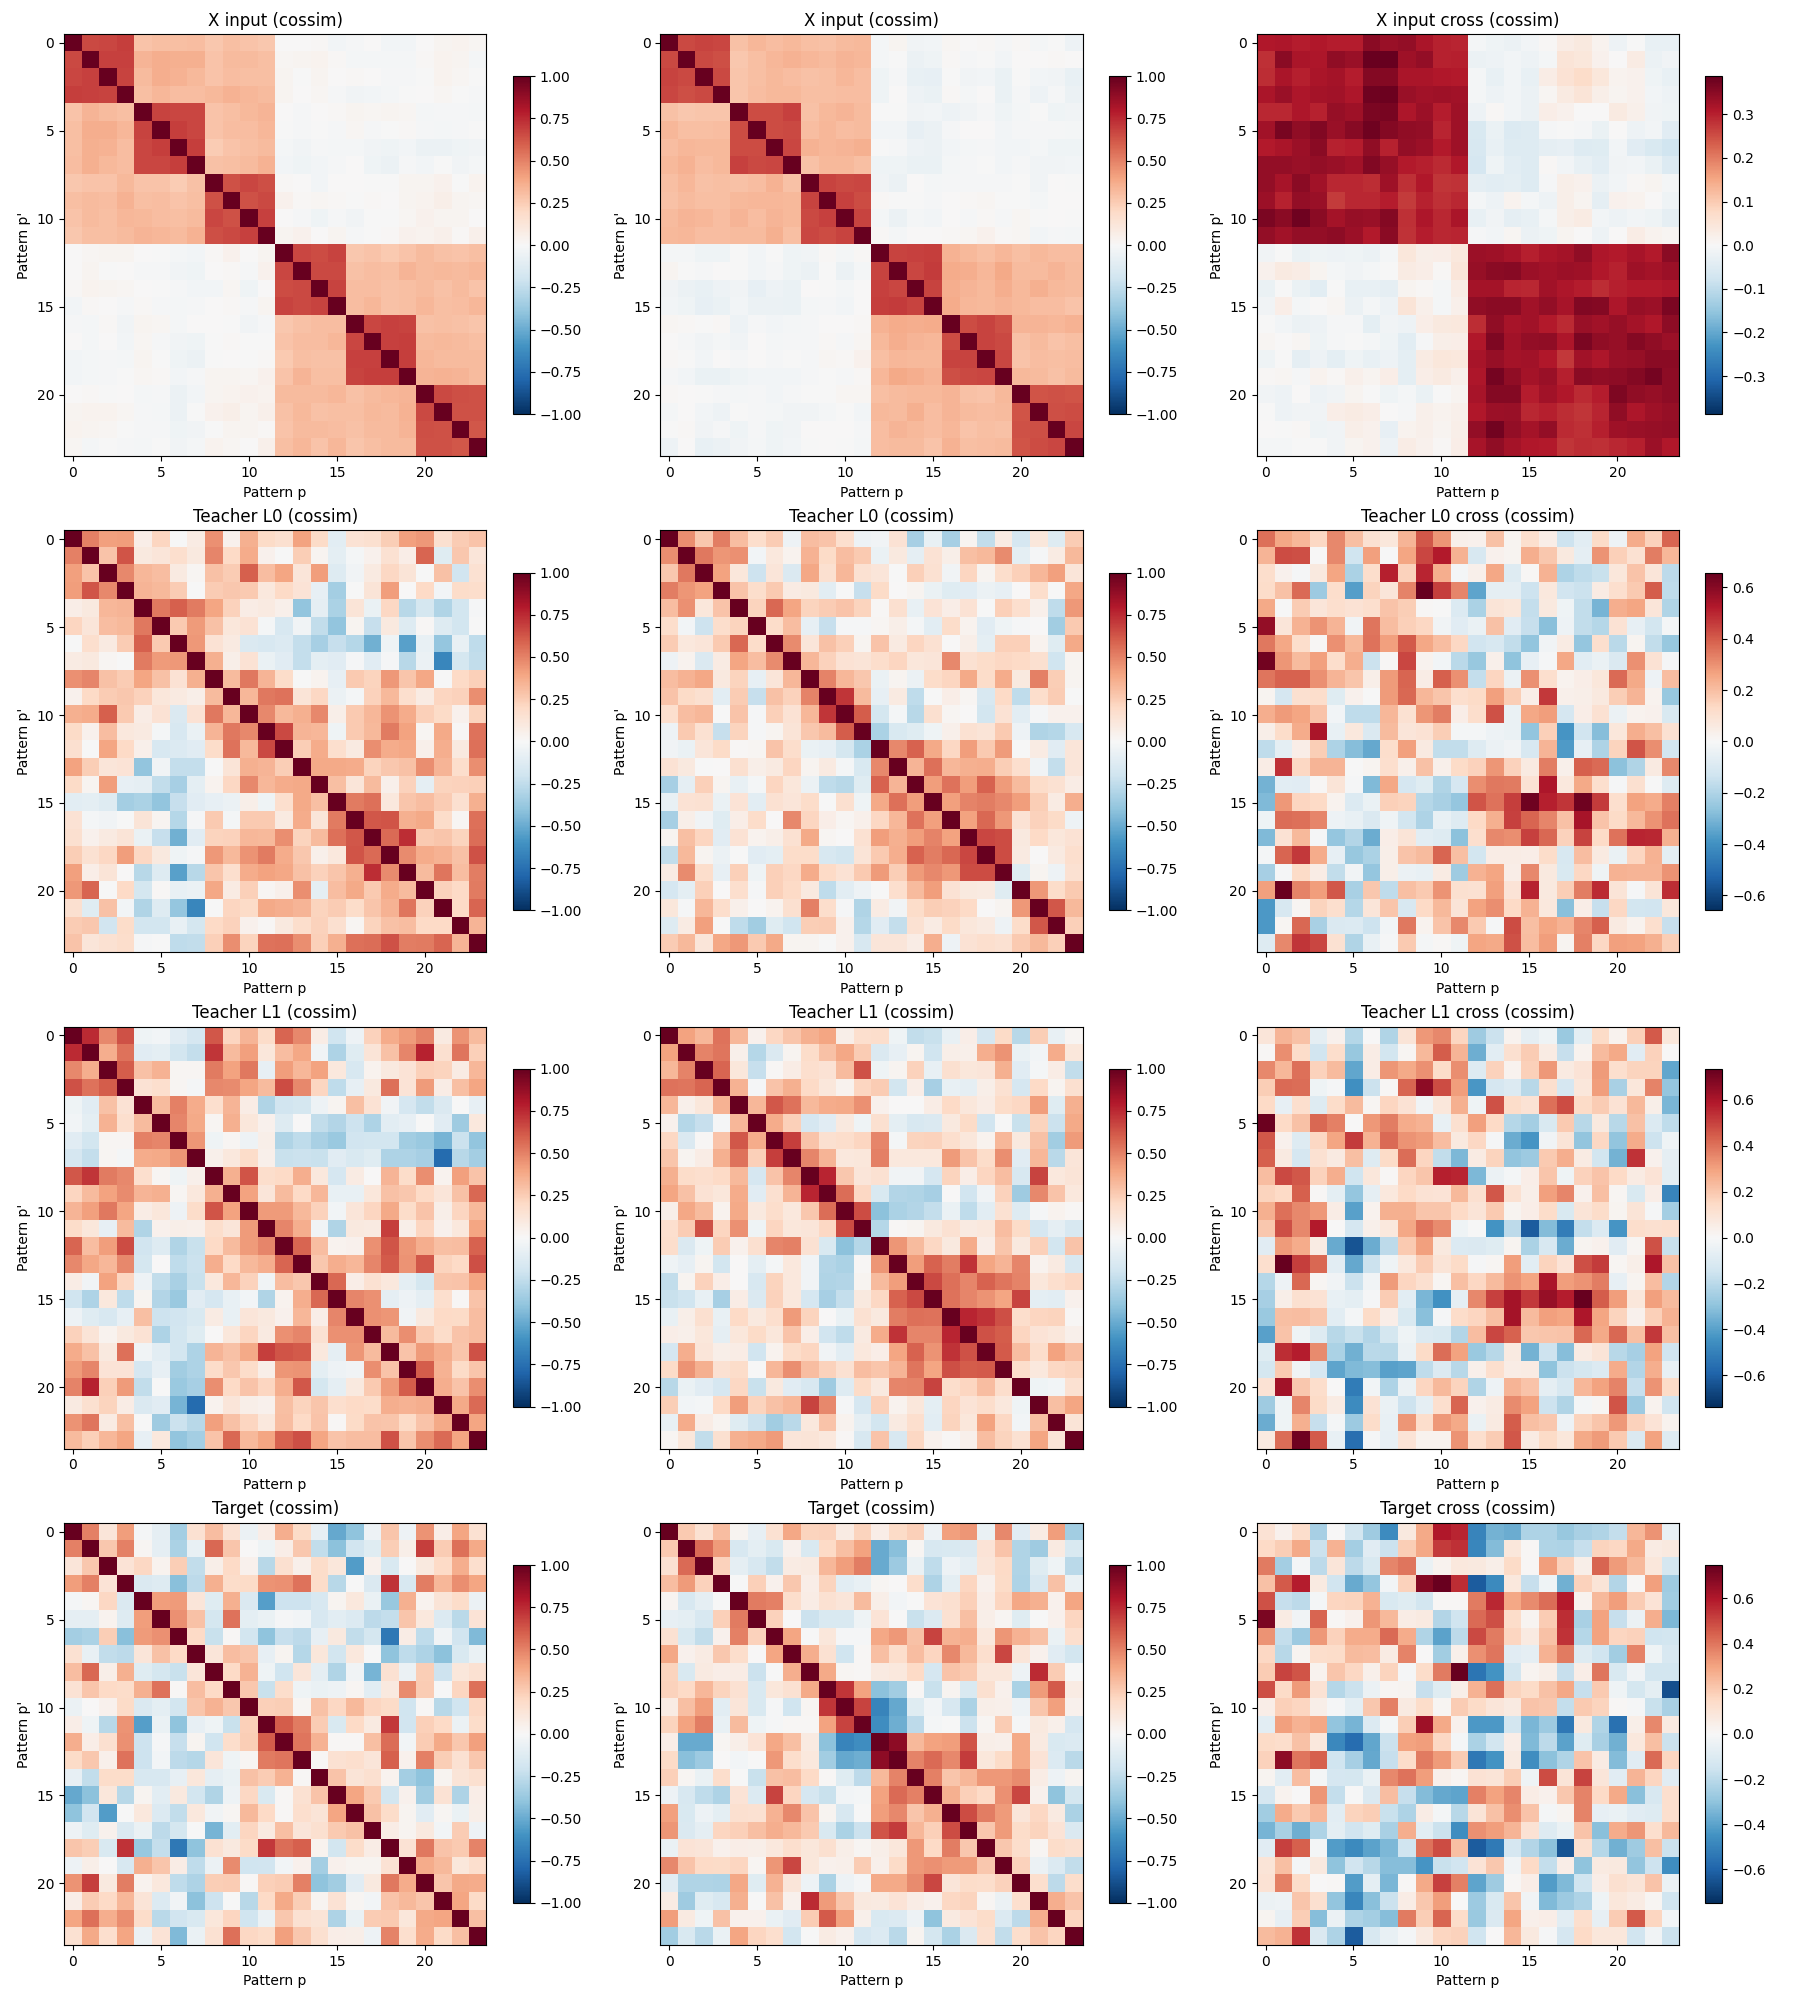

In [12]:
X_tr, Y_tr = jnp.array(X_train), jnp.array(Y_train)
X_te, Y_te = jnp.array(X_test), jnp.array(Y_test)

_ = plot_data_kernels(X_train, X_test, cossim=COSSIM,
                      teacher_params=teacher_params, beta=TASK_KW.get("beta", 1.0))

In [13]:
# Initialize networks
key = jax.random.key(0)
k1, k2 = jax.random.split(key)

d_out = Y_train.shape[-1]
params_shallow = init_shallow(k1, D, d_out, sigma=SIGMA)
params_deep = init_deep(k2, D, d_out, width=N, depth=DEPTH, sigma=SIGMA)

print(f"Shallow: {[w.shape for w in params_shallow]}")
print(f"Deep:    {[w.shape for w in params_deep]}")
print(f"muP: {MUP}, NTP: {NTP}, phi: {PHI}, sigma: {SIGMA}")

Shallow: [(24, 1024)]
Deep:    [(1024, 1024), (1024, 1024), (24, 1024)]
muP: True, NTP: True, phi: tanh, sigma: 0.8


In [ ]:
# Train both networks on train split
shared_config = dict(branching=BRANCHING, D=D, N=N, depth=DEPTH, sigma=SIGMA, phi=PHI)

print("=== Shallow ===")
params_shallow_trained, curves_shallow = train(
    params_shallow, X_tr, Y_tr, kappa0=KAPPA0, ds=DS, s_max=S_MAX, sigma=SIGMA,
    x_test=X_te, y_test=Y_te, mup=MUP, ntp=NTP, phi=PHI, cossim=COSSIM,
    run_name="shallow", config={"arch": "shallow", **shared_config},
)

print("\n=== Deep ===")
params_deep_trained, curves_deep = train(
    params_deep, X_tr, Y_tr, kappa0=KAPPA0, ds=DS, s_max=S_MAX, sigma=SIGMA,
    x_test=X_te, y_test=Y_te, mup=MUP, ntp=NTP, phi=PHI, cossim=COSSIM,
    run_name=f"deep-{DEPTH}", config={"arch": "deep", **shared_config},
)

print(f"\nShallow test MSE: {curves_shallow['mse_test'][-1]:.6f}")
print(f"Deep    test MSE: {curves_deep['mse_test'][-1]:.6f}")

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /nfs/nhome/live/jbauer/.netrc.


=== Shallow ===


wandb: Currently logged in as: japhba (japhba-personal) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Training with ds=1.00e-03, s_max=10000.0, eta=1.74e-07, max_steps=10000000 | x: {CudaDevice(id=0)}, y: {CudaDevice(id=0)}, params: {'W0': {CudaDevice(id=0)}}


Training:   0%|          | 0.00/10000.00s [00:00<?, ?s/s]

E0402 16:46:54.376905  347716 xtile_compiler.cc:399] Fusion: gemm_fusion_dot_general.20 = f32[24,24]{1,0} fusion(constant.33, get-tuple-element.6), kind=kCustom, calls=gemm_fusion_dot_general.20_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"4","output_tiles":[{"sizes":["64","256"]}],"num_ctas":1,"num_stages":4,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0402 16:46:54.377067  347716 xtile_compiler.cc:401] Computation: gemm_fusion_dot_general.20_computation.clone {
  parameter_0 = f32[24,256]{1,0} parameter(0)
  parameter_1 = f32[24,256]{1,0} parameter(1)
  constant_357 = f32[] constant(0.0625)
  broadcast.61 = f32[24,256]{1,0} broadcast(constant_357), dimensions={}
  mul.260 = f32[24,256]{1,0} multiply(parameter_1, broadcast.61)
  

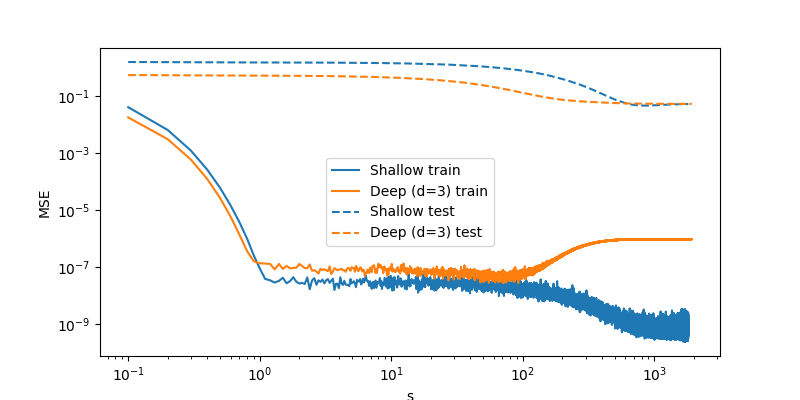

In [ ]:
_ = plot_loss_curves(curves_shallow, curves_deep, DEPTH)

In [ ]:
_ = plot_shallow_kernels(params_shallow_trained, X_tr, X_te, mup=MUP, ntp=NTP, phi=PHI, cossim=COSSIM)

In [ ]:
_ = plot_deep_kernels(params_deep_trained, X_tr, X_te, mup=MUP, ntp=NTP, phi=PHI, cossim=COSSIM)

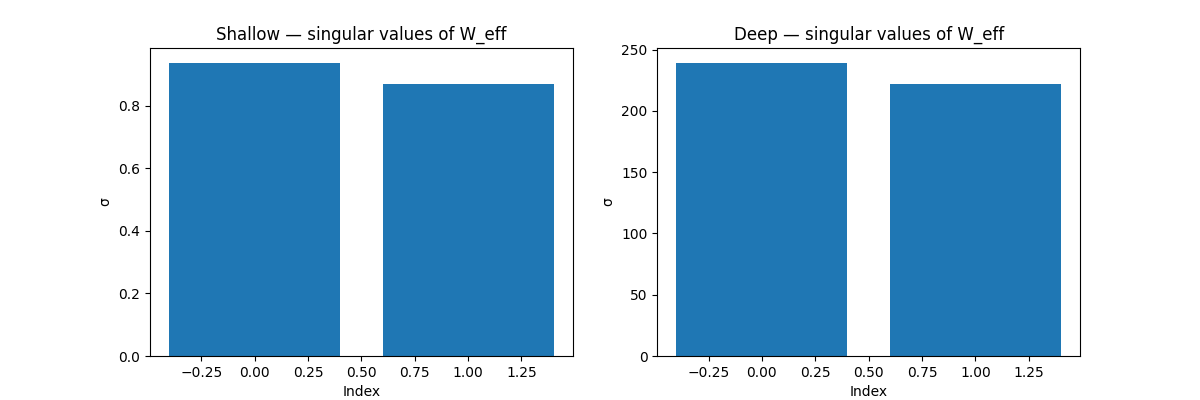

In [ ]:
_ = plot_effective_svd(params_shallow_trained, params_deep_trained)